In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [4]:
dataset_path = Path('data/nodes/6nodes.csv')
df = pd.read_csv(dataset_path,  dtype={'run_id': str})

df['run_id'].value_counts()
df.groupby('run_id')['cid'].nunique().value_counts()

cid
6    56
5     1
Name: count, dtype: int64

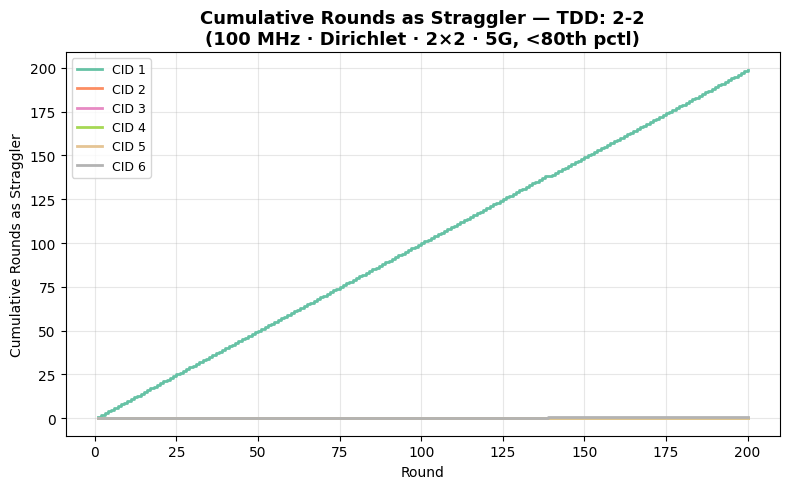

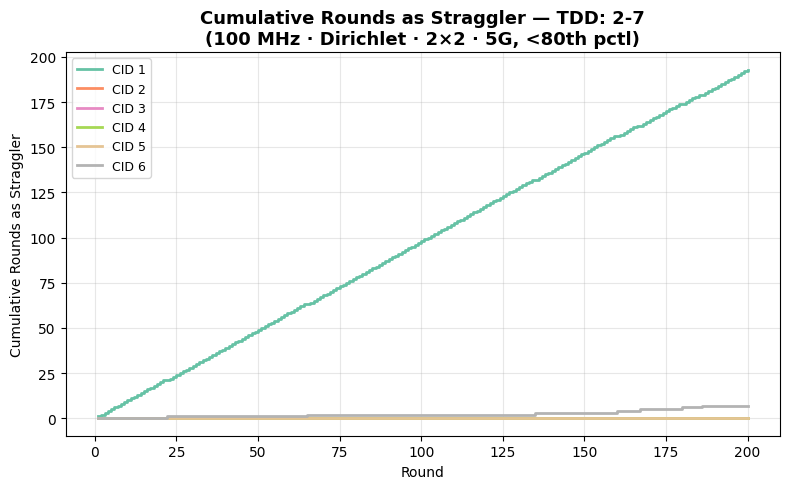

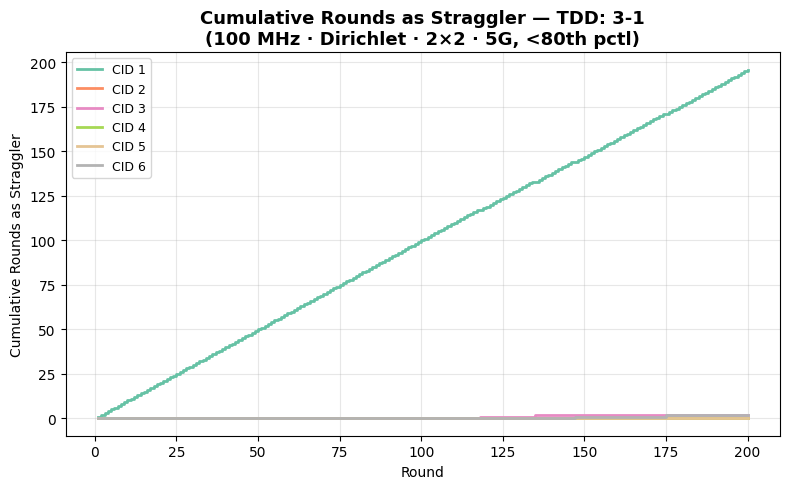

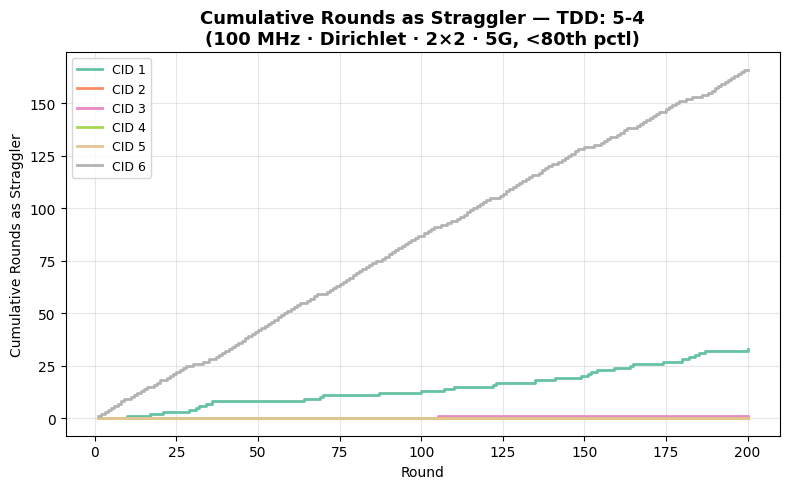

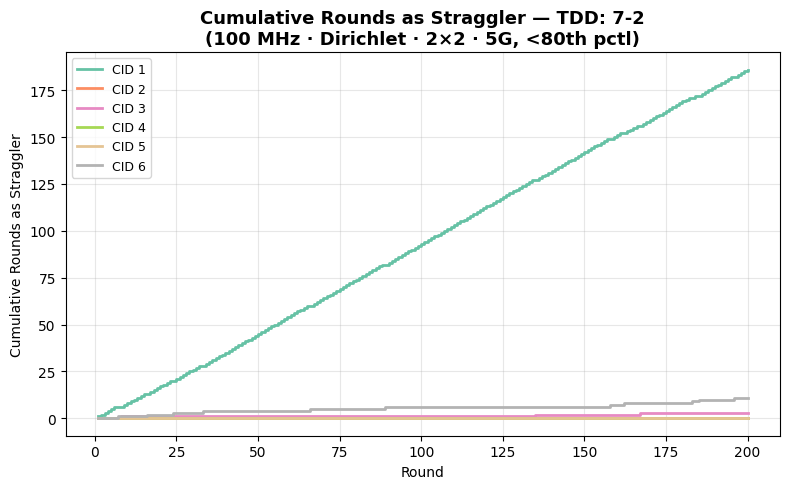

In [5]:
from collections import Counter
# Filter: 100 MHz, Dirichlet, 2x2, wwan
mask = (
    (df['bandwidth'] == '100 MHz') &
    (df['distribution'] == 'dirichlet') &
    (df['rank']== '2x2') &
    (df['network'] == 'wwan') &
    (df['nodes'] == '6N')
)

filtered = df[mask].copy()
filtered['total_time'] = filtered['train_time'] + filtered['uplink_latency'] + filtered['downlink_latency']

# Per-CID 80th percentile filter
filtered = filtered[filtered.groupby('cid')['total_time'].transform(lambda x: x < x.quantile(0.80))]

straggler = filtered.loc[filtered.groupby(['tdd', 'round'])['total_time'].idxmax()]

cids = sorted(filtered['cid'].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(cids)))
cid_colors = {c: colors[i] for i, c in enumerate(cids)}

for tdd in sorted(straggler['tdd'].unique()):
    sub = straggler[straggler['tdd'] == tdd].sort_values('round')
    fig, ax = plt.subplots(figsize=(8, 5))

    for cid in cids:
        # Cumulative count of rounds where this CID was straggler
        is_straggler = (sub['cid'] == cid).astype(int).cumsum()
        ax.step(sub['round'].values, is_straggler.values, where='post',
                label=f'CID {int(cid)}', color=cid_colors[cid], linewidth=2)

    ax.set_title(f'Cumulative Rounds as Straggler — TDD: {tdd}\n(100 MHz · Dirichlet · 2×2 · 5G, <80th pctl)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel('Cumulative Rounds as Straggler')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

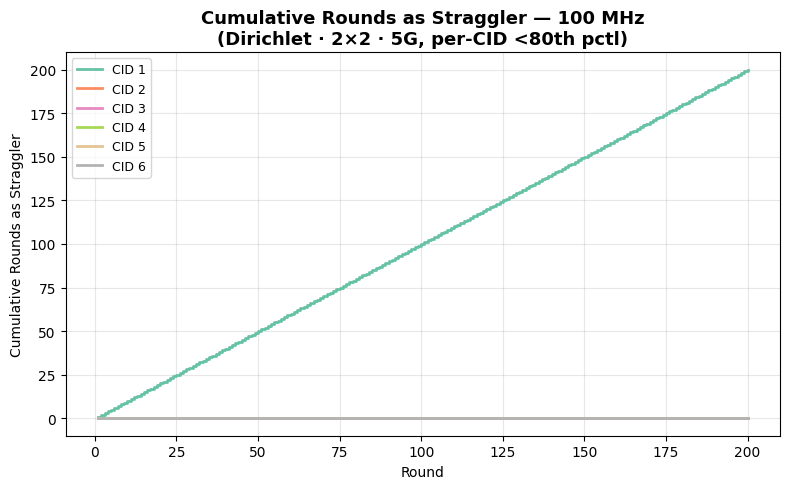

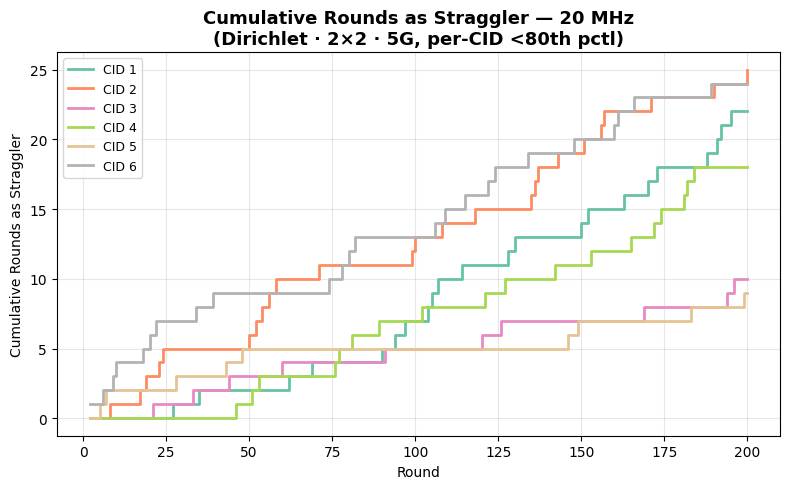

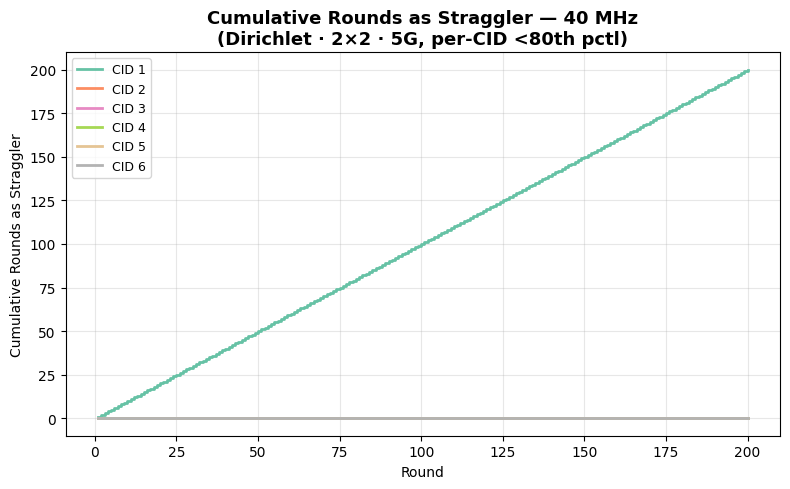

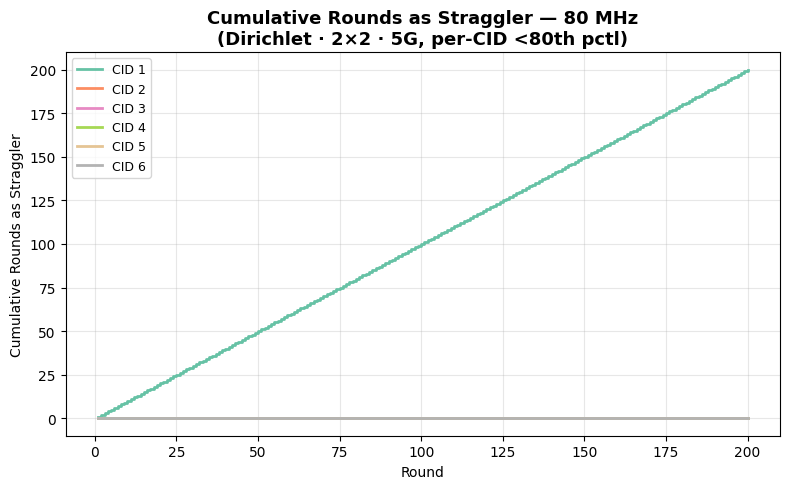

In [6]:
mask = (
    (df['distribution'] == 'dirichlet') &
    (df['rank'] == '2x2') &
    (df['network'] == 'wwan') &
    (df['nodes'] == '6N') &
    (df['tdd'] == '2-2')  # fix tdd, vary bandwidth
)

filtered = df[mask].copy()
filtered['total_time'] = filtered['train_time'] + filtered['uplink_latency'] + filtered['downlink_latency']

# Per-CID 80th percentile filter
filtered = filtered[filtered.groupby('cid')['total_time'].transform(lambda x: x < x.quantile(0.80))]

straggler = filtered.loc[filtered.groupby(['bandwidth', 'round'])['total_time'].idxmax()]

cids = sorted(filtered['cid'].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(cids)))
cid_colors = {c: colors[i] for i, c in enumerate(cids)}

for bw in sorted(straggler['bandwidth'].unique()):
    sub = straggler[straggler['bandwidth'] == bw].sort_values('round')
    fig, ax = plt.subplots(figsize=(8, 5))

    for cid in cids:
        is_straggler = (sub['cid'] == cid).astype(int).cumsum()
        ax.step(sub['round'].values, is_straggler.values, where='post',
                label=f'CID {int(cid)}', color=cid_colors[cid], linewidth=2)

    ax.set_title(f'Cumulative Rounds as Straggler — {bw}\n(Dirichlet · 2×2 · 5G, per-CID <80th pctl)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Round')
    ax.set_ylabel('Cumulative Rounds as Straggler')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
filtered = df[
    (df['bandwidth'] == '100 MHz') &
    (df['distribution'] == 'dirichlet') &
    (df['rank'] == '2x2') &
    (df['network'] == 'wwan') &
    (df['nodes'] == '6N')
].copy()

In [9]:
# Compute variance of num-examples per client
variance_per_cid = filtered.groupby('cid')['num-examples'].mean()

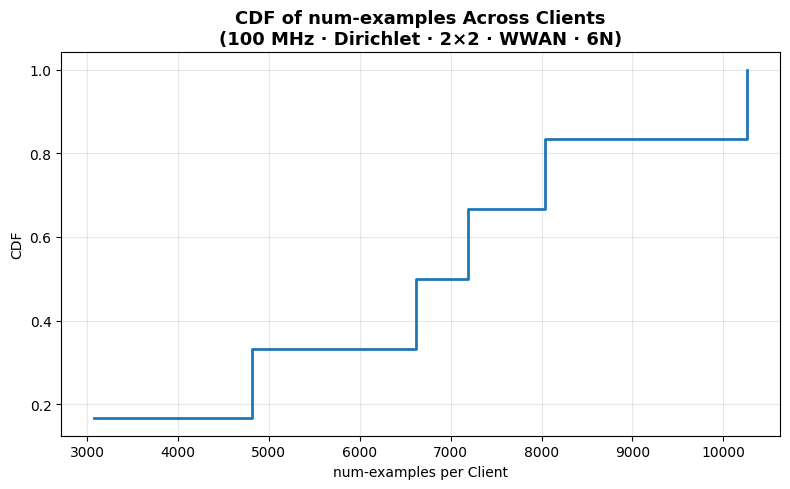

In [10]:
examples_per_cid = filtered.groupby('cid')['num-examples'].first()

sorted_ex = np.sort(examples_per_cid.values)
cdf = np.arange(1, len(sorted_ex) + 1) / len(sorted_ex)

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(sorted_ex, cdf, linewidth=2, where='post')
ax.set_xlabel('num-examples per Client')
ax.set_ylabel('CDF')
ax.set_title('CDF of num-examples Across Clients\n(100 MHz · Dirichlet · 2×2 · WWAN · 6N)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

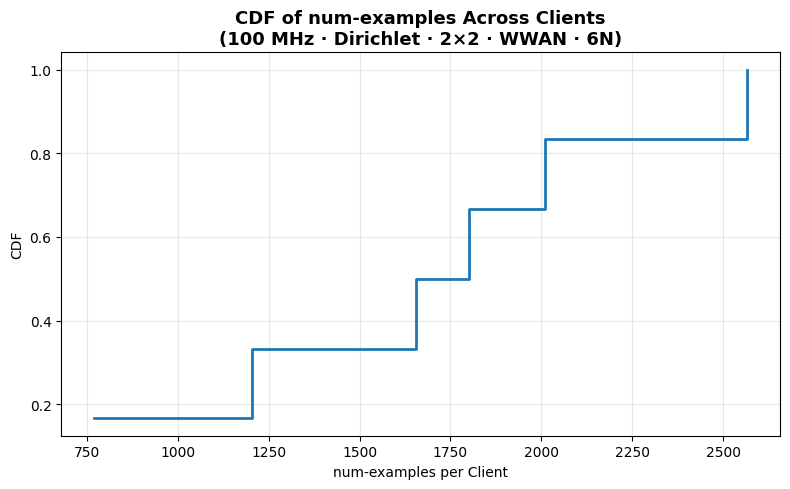

In [15]:
examples_per_cid = filtered.groupby('cid')['num-eval-examples'].first()

sorted_ex = np.sort(examples_per_cid.values)
cdf = np.arange(1, len(sorted_ex) + 1) / len(sorted_ex)

fig, ax = plt.subplots(figsize=(8, 5))
ax.step(sorted_ex, cdf, linewidth=2, where='post')
ax.set_xlabel('num-examples per Client')
ax.set_ylabel('CDF')
ax.set_title('CDF of num-examples Across Clients\n(100 MHz · Dirichlet · 2×2 · WWAN · 6N)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
median_examples = filtered.groupby('cid')['num-examples'].median()
median_eval_examples = filtered.groupby('cid')['num-eval-examples'].median()
filtered['normalized_train_time'] = filtered['train_time'].groupby('cid') / median_examples
filtered['normalized_eval_time'] = filtered['eval_time']/ median_eval_examples

filtered['norm_round_time'] = (filtered['normalized_train_time']
                          + filtered['uplink_latency']
                          + filtered['downlink_latency']
                          + filtered['normalized_eval_time'])

for tdd in sorted(filtered['tdd'].unique()):
    sub = filtered[filtered['tdd'] == tdd]
    data = [sub[sub['cid'] == cid]['norm_round_time'].values for cid in cids]

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, tick_labels=[f'CID {int(c)}' for c in cids], patch_artist=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(f'Normalized Round Time per Node — TDD: {tdd}\n(100 MHz · Dirichlet · 2×2 · 5G, normalized to median examples)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Total Round Time (s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

KeyError: 'cid'